# Кузьмичев Никита
## **Домашние задания №8-9**

### Тема: PyTorch 101 b основы оптимизации обучения.

##### **1. Импорты, seed и устройство**

In [1]:
# %pip install torch torchvision torchaudio

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib
%matplotlib inline 
import matplotlib.pyplot as plt

import numpy as np
import json
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Создаем нужные папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

Используемое устройство: cpu


##### **2. Данные и DataLoader**

In [3]:
# Загрузка EMNIST(split="balanced")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

In [4]:
# Разбиение train на train и val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity-check
for x, y in train_loader:
    print(f"Размер батча (X): {x.shape}")
    print(f"Размер меток (Y): {y.shape}")
    print(f"Диапазон значений: min={x.min().item():.2f}, max={x.max().item():.2f}")
    break

Размер батча (X): torch.Size([128, 1, 28, 28])
Размер меток (Y): torch.Size([128])
Диапазон значений: min=-1.00, max=1.00


##### **3. Модель MLP и цикл обучения**

In [5]:
class MLPBase(nn.Module):
    def __init__(self, use_dropout=False, use_bn=False):
        super().__init__()
        self.flatten = nn.Flatten()
        self.use_dropout = use_dropout
        self.use_bn = use_bn
        
        # EMNIST image size is 28x28=784. "balanced" split has 47 classes.
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else nn.Identity()
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3) if use_dropout else nn.Identity()
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128) if use_bn else nn.Identity()
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3) if use_dropout else nn.Identity()
        
        self.fc3 = nn.Linear(128, 47)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.drop1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        
        x = self.fc3(x)
        return x

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [7]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            running_loss += loss.item() * x.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

#### Рубрика: ЭКСПЕРИМЕНТЫ!!!

##### **Оболочка для них**

In [8]:
results = []
histories = {}
best_e4_state = None

def run_experiment(model, name, optimizer_type='Adam', lr=1e-3, epochs=10, patience=None, momentum=0, weight_decay=0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        print(f"[{name}] Epoch {epoch+1}/{epochs} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if patience and epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
            
    return history, best_val_acc, min(history['val_loss']), len(history['train_loss']), best_model_state

##### **4. Часть A (S08): регуляризация и переобучение (обязательно)**

In [9]:
print("=== E1: Base ===")
model_e1 = MLPBase(use_dropout=False, use_bn=False)
h1, b_acc1, b_loss1, ep1, _ = run_experiment(model_e1, "E1", epochs=10)
results.append(['E1', 'EMNIST', 42, '256-128', 'Adam', 1e-3, 0, 0, ep1, b_acc1, b_loss1])

=== E1: Base ===
[E1] Epoch 1/10 | Val Loss: 0.8596 | Val Acc: 0.7414
[E1] Epoch 2/10 | Val Loss: 0.6968 | Val Acc: 0.7778
[E1] Epoch 3/10 | Val Loss: 0.6146 | Val Acc: 0.8024
[E1] Epoch 4/10 | Val Loss: 0.5608 | Val Acc: 0.8149
[E1] Epoch 5/10 | Val Loss: 0.5452 | Val Acc: 0.8242
[E1] Epoch 6/10 | Val Loss: 0.5275 | Val Acc: 0.8277
[E1] Epoch 7/10 | Val Loss: 0.5244 | Val Acc: 0.8294
[E1] Epoch 8/10 | Val Loss: 0.5127 | Val Acc: 0.8346
[E1] Epoch 9/10 | Val Loss: 0.4976 | Val Acc: 0.8393
[E1] Epoch 10/10 | Val Loss: 0.5061 | Val Acc: 0.8362


In [10]:
print("=== E2: Dropout ===")
model_e2 = MLPBase(use_dropout=True, use_bn=False)
h2, b_acc2, b_loss2, ep2, _ = run_experiment(model_e2, "E2", epochs=10)
results.append(['E2', 'EMNIST', 42, '256-128, Dropout=0.3', 'Adam', 1e-3, 0, 0, ep2, b_acc2, b_loss2])

=== E2: Dropout ===
[E2] Epoch 1/10 | Val Loss: 0.9083 | Val Acc: 0.7256
[E2] Epoch 2/10 | Val Loss: 0.7583 | Val Acc: 0.7674
[E2] Epoch 3/10 | Val Loss: 0.6923 | Val Acc: 0.7807
[E2] Epoch 4/10 | Val Loss: 0.6485 | Val Acc: 0.7895
[E2] Epoch 5/10 | Val Loss: 0.6186 | Val Acc: 0.7993
[E2] Epoch 6/10 | Val Loss: 0.6047 | Val Acc: 0.8050
[E2] Epoch 7/10 | Val Loss: 0.5952 | Val Acc: 0.8047
[E2] Epoch 8/10 | Val Loss: 0.5744 | Val Acc: 0.8098
[E2] Epoch 9/10 | Val Loss: 0.5697 | Val Acc: 0.8121
[E2] Epoch 10/10 | Val Loss: 0.5507 | Val Acc: 0.8184


In [11]:
print("=== E3: BatchNorm ===")
model_e3 = MLPBase(use_dropout=False, use_bn=True)
h3, b_acc3, b_loss3, ep3, _ = run_experiment(model_e3, "E3", epochs=10)
results.append(['E3', 'EMNIST', 42, '256-128, BatchNorm', 'Adam', 1e-3, 0, 0, ep3, b_acc3, b_loss3])

=== E3: BatchNorm ===
[E3] Epoch 1/10 | Val Loss: 0.6235 | Val Acc: 0.8016
[E3] Epoch 2/10 | Val Loss: 0.5072 | Val Acc: 0.8283
[E3] Epoch 3/10 | Val Loss: 0.4966 | Val Acc: 0.8336
[E3] Epoch 4/10 | Val Loss: 0.4872 | Val Acc: 0.8348
[E3] Epoch 5/10 | Val Loss: 0.4654 | Val Acc: 0.8439
[E3] Epoch 6/10 | Val Loss: 0.4569 | Val Acc: 0.8468
[E3] Epoch 7/10 | Val Loss: 0.4649 | Val Acc: 0.8457
[E3] Epoch 8/10 | Val Loss: 0.4714 | Val Acc: 0.8441
[E3] Epoch 9/10 | Val Loss: 0.4626 | Val Acc: 0.8471
[E3] Epoch 10/10 | Val Loss: 0.4755 | Val Acc: 0.8457


In [12]:
print("=== E4: EarlyStopping (на основе лучшего из E2/E3) ===")
# Обычно BN сходится быстрее и дает лучший скор. 
# В коде выбираем архитектуру E3 для E4.
model_e4 = MLPBase(use_dropout=False, use_bn=True) 
h4, b_acc4, b_loss4, ep4, best_e4_state = run_experiment(model_e4, "E4", epochs=20, patience=3)
results.append(['E4', 'EMNIST', 42, '256-128, BatchNorm, ES', 'Adam', 1e-3, 0, 0, ep4, b_acc4, b_loss4])
histories['E4'] = h4

# Сохранение лучшей модели E4
torch.save(best_e4_state, 'artifacts/best_model.pt')
with open('artifacts/best_config.json', 'w') as f:
    json.dump({"dataset": "EMNIST", "architecture": "256-128, BatchNorm", "optimizer": "Adam", "lr": 1e-3, "seed": 42}, f)

=== E4: EarlyStopping (на основе лучшего из E2/E3) ===
[E4] Epoch 1/20 | Val Loss: 0.6025 | Val Acc: 0.8104
[E4] Epoch 2/20 | Val Loss: 0.5161 | Val Acc: 0.8288
[E4] Epoch 3/20 | Val Loss: 0.4820 | Val Acc: 0.8392
[E4] Epoch 4/20 | Val Loss: 0.4678 | Val Acc: 0.8421
[E4] Epoch 5/20 | Val Loss: 0.4659 | Val Acc: 0.8438
[E4] Epoch 6/20 | Val Loss: 0.4550 | Val Acc: 0.8483
[E4] Epoch 7/20 | Val Loss: 0.4674 | Val Acc: 0.8434
[E4] Epoch 8/20 | Val Loss: 0.4620 | Val Acc: 0.8461
[E4] Epoch 9/20 | Val Loss: 0.4727 | Val Acc: 0.8459
Early stopping at epoch 9


##### **5. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)**

In [13]:
print("=== O1: LR слишком большой ===")
model_o1 = MLPBase(use_dropout=False, use_bn=True)
h_o1, b_acc_o1, b_loss_o1, ep_o1, _ = run_experiment(model_o1, "O1", lr=1e-1, epochs=6)
results.append(['O1', 'EMNIST', 42, '256-128, BN', 'Adam', 1e-1, 0, 0, ep_o1, b_acc_o1, b_loss_o1])
histories['O1'] = h_o1

print("=== O2: LR слишком маленький ===")
model_o2 = MLPBase(use_dropout=False, use_bn=True)
h_o2, b_acc_o2, b_loss_o2, ep_o2, _ = run_experiment(model_o2, "O2", lr=1e-5, epochs=6)
results.append(['O2', 'EMNIST', 42, '256-128, BN', 'Adam', 1e-5, 0, 0, ep_o2, b_acc_o2, b_loss_o2])
histories['O2'] = h_o2

=== O1: LR слишком большой ===
[O1] Epoch 1/6 | Val Loss: 0.8714 | Val Acc: 0.7234
[O1] Epoch 2/6 | Val Loss: 0.7696 | Val Acc: 0.7495
[O1] Epoch 3/6 | Val Loss: 0.6929 | Val Acc: 0.7782
[O1] Epoch 4/6 | Val Loss: 0.6525 | Val Acc: 0.7911
[O1] Epoch 5/6 | Val Loss: 0.6487 | Val Acc: 0.7992
[O1] Epoch 6/6 | Val Loss: 0.6213 | Val Acc: 0.8037
=== O2: LR слишком маленький ===
[O2] Epoch 1/6 | Val Loss: 3.1163 | Val Acc: 0.3623
[O2] Epoch 2/6 | Val Loss: 2.7050 | Val Acc: 0.5013
[O2] Epoch 3/6 | Val Loss: 2.4311 | Val Acc: 0.5635
[O2] Epoch 4/6 | Val Loss: 2.2110 | Val Acc: 0.5992
[O2] Epoch 5/6 | Val Loss: 2.0247 | Val Acc: 0.6228
[O2] Epoch 6/6 | Val Loss: 1.8665 | Val Acc: 0.6429


In [14]:
print("=== O3: SGD + Momentum + Weight Decay ===")
model_o3 = MLPBase(use_dropout=False, use_bn=True)
h_o3, b_acc_o3, b_loss_o3, ep_o3, _ = run_experiment(model_o3, "O3", optimizer_type='SGD', lr=1e-2, momentum=0.9, weight_decay=1e-4, epochs=10)
results.append(['O3', 'EMNIST', 42, '256-128, BN', 'SGD', 1e-2, 0.9, 1e-4, ep_o3, b_acc_o3, b_loss_o3])

=== O3: SGD + Momentum + Weight Decay ===
[O3] Epoch 1/10 | Val Loss: 0.6488 | Val Acc: 0.7988
[O3] Epoch 2/10 | Val Loss: 0.5469 | Val Acc: 0.8242
[O3] Epoch 3/10 | Val Loss: 0.5057 | Val Acc: 0.8347
[O3] Epoch 4/10 | Val Loss: 0.4810 | Val Acc: 0.8411
[O3] Epoch 5/10 | Val Loss: 0.4811 | Val Acc: 0.8389
[O3] Epoch 6/10 | Val Loss: 0.4580 | Val Acc: 0.8497
[O3] Epoch 7/10 | Val Loss: 0.4576 | Val Acc: 0.8497
[O3] Epoch 8/10 | Val Loss: 0.4529 | Val Acc: 0.8498
[O3] Epoch 9/10 | Val Loss: 0.4548 | Val Acc: 0.8504
[O3] Epoch 10/10 | Val Loss: 0.4568 | Val Acc: 0.8501


##### **6. Артефакты**

In [15]:
# Сохранение таблицы
df = pd.DataFrame(results, columns=['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'momentum', 'weight_decay', 'epochs_trained', 'best_val_accuracy', 'best_val_loss'])
df.to_csv('artifacts/runs.csv', index=False)

FINAL TEST ACCURACY (E4): 0.8466


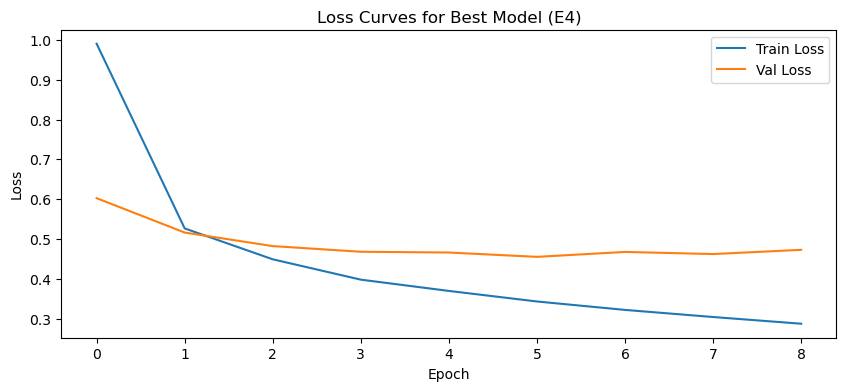

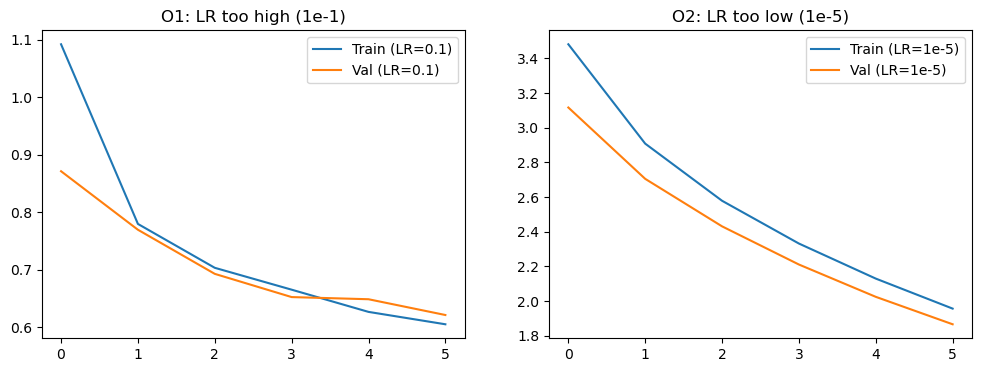

In [16]:
# Оценка лучшей модели на Test (1 раз)
model_test = MLPBase(use_dropout=False, use_bn=True)
model_test.load_state_dict(torch.load('artifacts/best_model.pt'))
model_test = model_test.to(device)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_test, test_loader, criterion)
print(f"FINAL TEST ACCURACY (E4): {test_acc:.4f}")

# График 1: Лучшая модель E4
plt.figure(figsize=(10, 4))
plt.plot(histories['E4']['train_loss'], label='Train Loss')
plt.plot(histories['E4']['val_loss'], label='Val Loss')
plt.title('Loss Curves for Best Model (E4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()

# График 2: Плохие LR (O1 и O2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(histories['O1']['train_loss'], label='Train (LR=0.1)')
ax1.plot(histories['O1']['val_loss'], label='Val (LR=0.1)')
ax1.set_title('O1: LR too high (1e-1)')
ax1.legend()
ax2.plot(histories['O2']['train_loss'], label='Train (LR=1e-5)')
ax2.plot(histories['O2']['val_loss'], label='Val (LR=1e-5)')
ax2.set_title('O2: LR too low (1e-5)')
ax2.legend()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()